## Analyis of Algorithm

In [56]:
library(terra)
library(sf)
library(dplyr)
library(lwgeom)
library(tidyverse)
library(tictoc)

In [57]:
getwd()

[1] "/home/etienne/Desktop/repos/Github_Enterprise/BSc_project/code"

### 1. Load in the data

In [58]:
  t0 <- tic()
r <- terra::rast("../data/thermal_rasters_FINAL/mean_v01emme.tif")

line <- sf::st_read("../data/Centerlines_FINAL/Emme_V01.shp", quiet = TRUE) |> sf::st_zm(TRUE, "ZM")


In [59]:
stopifnot(terra::nlyr(r) == 1) # if not only one layer
names(r) <- "T"
if (terra::is.lonlat(r)) stop("Raster must be in a metric CRS.")


In [60]:
rres   <- terra::res(r)
cell_m <- mean(rres)



In [61]:
  if (!is.na(sf::st_crs(line)) &&
      !identical(terra::crs(r), sf::st_crs(line)$wkt)) {
    line <- sf::st_transform(line, terra::crs(r))

}

# This specific object has only one line, somehtimes there are multible ->  then
# we need to do a join.
line

Simple feature collection with 1 feature and 2 fields
Geometry type: LINESTRING
Dimension:     XY
Bounding box:  xmin: 2607224 ymin: 1205048 xmax: 2620465 ymax: 1226331
Projected CRS: CH1903+ / LV95
  NAME   Length                       geometry
1 Emme 30165.01 LINESTRING (2620465 1205048...

In [62]:
g <- sf::st_union(line)

Dont realy know why this is. It seems to me like this is necessairy because not all data is the same -> Better leave it in

---
### Parameters of the Function

In [63]:
step_m            = 500       # slab length along centerline (m)
buffer_px         = 3         # corridor half-width for reference T (pixels)
delta_C           = 1.0       # temperature anomaly threshold (deg C)
min_patch_area_m2 = 2         # drop patches smaller than this
round_to          = 0.1       # round temperatures to this precision
slab_halfwidth_m  = 60        # lateral half-width of slab polygons (m)
connect_diagonals = TRUE      # 8-connectivity when dissolving patches
union_chunk_size  = 50000L    # max cells per dissolve chunk

In [64]:
  if (inherits(g, "sfc_GEOMETRYCOLLECTION"))
    g <- sf::st_collection_extract(g, "LINESTRING")
  if (inherits(g, "sfc_MULTILINESTRING")) {
    g <- sf::st_line_merge(g)
    if (inherits(g, "sfc_GEOMETRYCOLLECTION"))
      g <- sf::st_collection_extract(g, "LINESTRING")
  }

In [65]:
  if (!inherits(g, "sfc_LINESTRING"))
    stop("Centerline must resolve to a LINESTRING.")
  line <- sf::st_sf(geometry = g)


In [66]:
  rfactor <- if (!is.null(round_to) && round_to > 0) 1 / round_to else NA_real_

rfactor

[1] 10

In [67]:
toc()


0.596 sec elapsed


**Timing**

This first set of steps is very fast. That was to be exected. terra only holds a pointer to the data in memory. Only upon evaluation, data is actually read. sf I am not quite shure. But it is also reasonable, that loading a single line into memory is not computationally expensive. So all the checks of coordinate reference systems etc.

---
### 2. Building slabs

In [100]:
tic("Building slaps")
L <- as.numeric(sf::st_length(line))
S <- step_m

# I am quite shure this has its good reasons why it is how it is.
# if seq yields NULL or something, then you still got a vector with a 0
pos <- sort(unique(c(0, seq(0,1, by = S/ L))))

# number of positions ?
npt <- length(pos)

# this returns a warning, if we e.g. want to do step size 5000m but
# the river segment is not even 5000 m long
if (npt < 2) stop("Too few stations for step = ", S)

In [101]:
# these are simple difference vectors 
from <- pos[1:(npt - 1)]
to   <- pos[2:npt]

k    <- length(from)

# not quite shure, why this is needed. This gets the
# geometry from the sf object which is a dataframe with a column holding the
# geometries
g1   <- sf::st_geometry(line)[1]

g1

Geometry set for 1 feature 
Geometry type: LINESTRING
Dimension:     XY
Bounding box:  xmin: 2607224 ymin: 1205048 xmax: 2620465 ymax: 1226331
Projected CRS: CH1903+ / LV95
LINESTRING (2620465 1205048, 2620390 1205056, 2...

In [106]:
# this returns a list filled with NULL
subs_list <- vector("list", k)

subs_list %>% head()

[[1]]
NULL

[[2]]
NULL

[[3]]
NULL

[[4]]
NULL

[[5]]
NULL

[[6]]
NULL


In [107]:
# from and to are both arrays
for (j in seq_len(k)) {
  subs_list[[j]] <- lwgeom::st_linesubstring(g1, from[j], to[j])
}

# ?do.call
# ok I see. do.call is like a map. It applies
# the function c() to every element of the subs list
subs <- do.call(c,subs_list)


subs %>% class()

# Ok and additionally it seems, like the objects
# inside subs_list interact with c() in a way that they
# get lumped together to a larger geometry object
# so this is a way of "gluing" the segments together to a single object

# ok now I understand what slabs are.
# these are polygons that got greated from
# a linestring (segments) via e buffer.
# the end of the buffer is flatt, to this
# sort of creates rectanlge
# 
slabs <- sf::st_buffer(subs,
                          dist        = slab_halfwidth_m,
                          endCapStyle = "FLAT",
                          joinStyle   = "MITRE",
                          mitreLimit  = 2)
slabs_sf <- sf::st_sf(geometry = slabs)

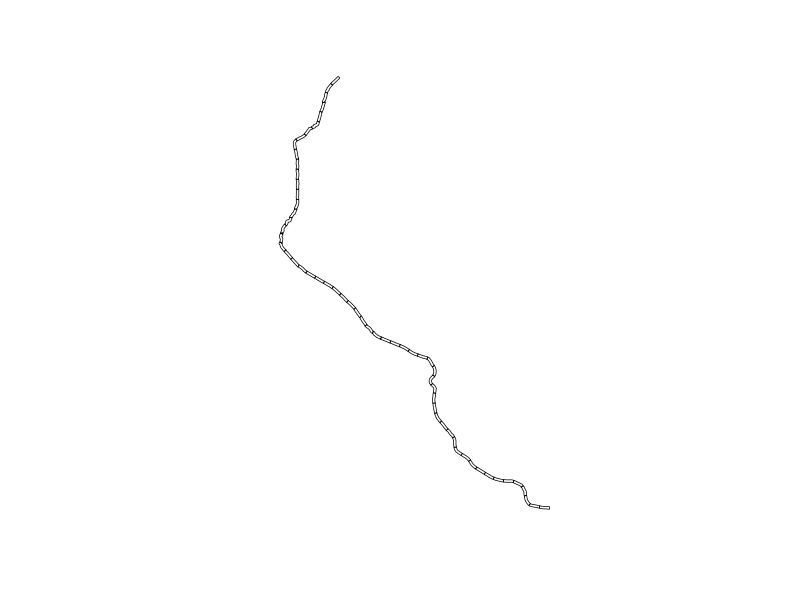

In [108]:
slabs_sf %>% plot()

These are nsome nice slaps ngl

In [109]:
toc()

2377.376 sec elapsed


**Timing**

This slap building steps also seems to be rather fast. No wonder, as the geodata in play here is very light weight and the rest are just native R functions. (So far this is great but Im rather certain, that the whole number crunching is up ahead)

---
### 3. Extract slab pixels

In [112]:
slabs_terra <- terra::vect(slabs_sf)

In [113]:
terra::extract(r, slabs_terra, cells = TRUE)

: [1m[33mError[39m:[22m
[33m![39m std::bad_alloc

This seems to be very very memory intensive. (It is, since this basically creates a dataframe that holds a row for every pixel.) Idk, this is maybe a super fast way of doing this whole reference temperature calculations if one has enough memory (I don't). But on the HPC i have plenty of memory.

I guess I will still try to find an alternative way of doing this here. Ofc, the computations over the resulting dataframe can be parallelized (because some of these reference temperature calculations are embarissingly parallel + every slab on its own is parallel too). But I can also parallelize this in terra (hopefully). I think I could build the buffer means using

rasterisation of thinner slaps -> zonal operation with the thiner slap raster. And then I could do reclassification of the big slaps using the means of the smaller slaps (median buffers) as burn in. Then all that would be left is some raster algebra.

The neat part is, that this is all powered by GDAL (like almost everything ofc.). So on the hpc i can just try to krank up the number of threads used by gdal and potentially allready get a decent speedup without even changing that much about the code.